In [5]:
# ============================================================
# ZESTY — COMPARADOR DE VOLATILIDAD: NVDA vs JNJ
# Continuación de prueba030426.ipynb
# Todos los gráficos con misma escala y colores consistentes
# ============================================================
# !pip install yfinance pandas matplotlib numpy scipy statsmodels

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.graphics.tsaplots import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import yfinance as yf

plt.style.use("seaborn-v0_8-whitegrid")

In [6]:
# ─── 0. CONFIGURACIÓN — cambia los tickers aquí ──────────────
TICKER_VOLATIL = "NVDA"   # Alta volatilidad
TICKER_ESTABLE = "JNJ"    # Baja volatilidad
PERIODO        = "2y"
VENTANA_ROLL   = 30       # Días para volatilidad rodante
LAGS           = 30       # Lags ACF / PACF
COLOR_V        = "#e84d3d"  # Rojo  → volátil
COLOR_E        = "#3d8ee8"  # Azul  → estable


In [7]:
# ─── 1. DESCARGA ─────────────────────────────────────────────
raw = yf.download([TICKER_VOLATIL, TICKER_ESTABLE],
                  period=PERIODO, interval="1d",
                  auto_adjust=True, progress=False)

def get_close(data, ticker):
    if isinstance(data.columns, pd.MultiIndex):
        return data["Close"][ticker].dropna()
    return data["Close"].dropna()

precio_nvda = get_close(raw, TICKER_VOLATIL)
precio_jnj  = get_close(raw, TICKER_ESTABLE)

ret_nvda = np.log(precio_nvda / precio_nvda.shift(1)).dropna() * 100
ret_jnj  = np.log(precio_jnj  / precio_jnj.shift(1)).dropna()  * 100

vol_d_nvda = ret_nvda.std();  vol_a_nvda = vol_d_nvda * np.sqrt(252)
vol_d_jnj  = ret_jnj.std();   vol_a_jnj  = vol_d_jnj  * np.sqrt(252)

vol_roll_nvda = ret_nvda.rolling(VENTANA_ROLL).std() * np.sqrt(252)
vol_roll_jnj  = ret_jnj.rolling(VENTANA_ROLL).std()  * np.sqrt(252)
idx_comun     = vol_roll_nvda.dropna().index.intersection(vol_roll_jnj.dropna().index)

print(f"✅ Datos listos")
print(f"   {TICKER_VOLATIL} — Vol. anual: {vol_a_nvda:.1f}%  |  Peor día: {ret_nvda.min():.1f}%")
print(f"   {TICKER_ESTABLE}  — Vol. anual: {vol_a_jnj:.1f}%  |  Peor día: {ret_jnj.min():.1f}%")
print(f"\n📊 {TICKER_VOLATIL} es {vol_a_nvda/vol_a_jnj:.1f}x más volátil que {TICKER_ESTABLE}")

✅ Datos listos
   NVDA — Vol. anual: 49.6%  |  Peor día: -18.6%
   JNJ  — Vol. anual: 17.9%  |  Peor día: -7.9%

📊 NVDA es 2.8x más volátil que JNJ


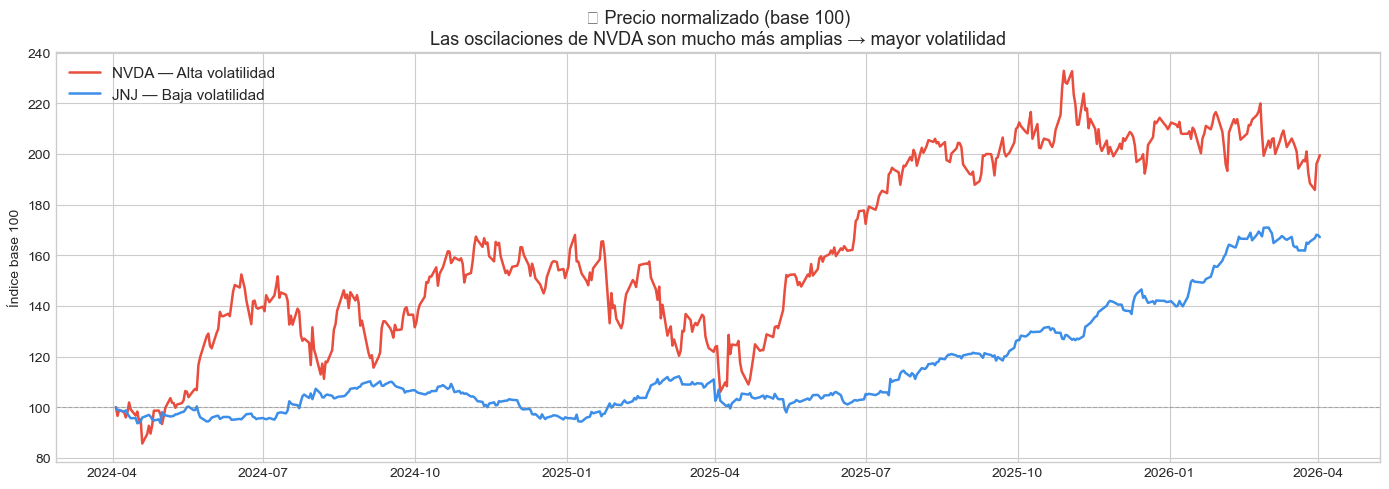

In [8]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 1 — Precio normalizado (base 100)
# ══════════════════════════════════════════════════════════════
base      = max(precio_nvda.index[0], precio_jnj.index[0])
norm_nvda = precio_nvda[precio_nvda.index >= base] / float(precio_nvda[precio_nvda.index >= base].iloc[0]) * 100
norm_jnj  = precio_jnj[precio_jnj.index   >= base] / float(precio_jnj[precio_jnj.index   >= base].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(norm_nvda.index, norm_nvda.values, color=COLOR_V, linewidth=1.8,
        label=f"{TICKER_VOLATIL} — Alta volatilidad")
ax.plot(norm_jnj.index,  norm_jnj.values,  color=COLOR_E, linewidth=1.8,
        label=f"{TICKER_ESTABLE} — Baja volatilidad")
ax.axhline(100, linestyle="--", color="gray", linewidth=0.8, alpha=0.5)
ax.set_title("① Precio normalizado (base 100)\n"
             "Las oscilaciones de NVDA son mucho más amplias → mayor volatilidad", fontsize=13)
ax.set_ylabel("Índice base 100")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


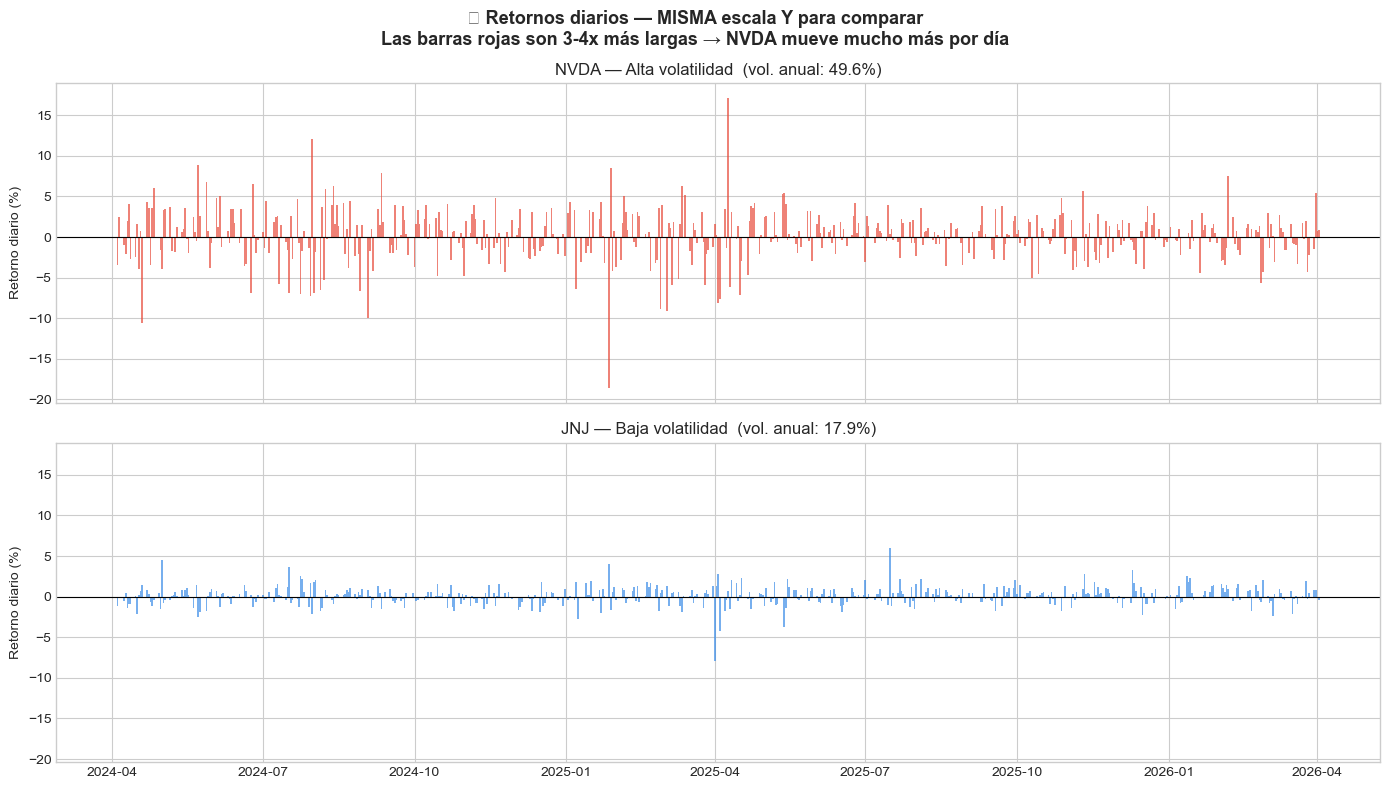

In [9]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 2 — Retornos diarios con MISMA escala Y (sharey=True)
# ══════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                sharex=True, sharey=True)

ax1.bar(ret_nvda.index, ret_nvda.values, color=COLOR_V, alpha=0.7, width=1)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Retorno diario (%)")
ax1.set_title(f"{TICKER_VOLATIL} — Alta volatilidad  (vol. anual: {vol_a_nvda:.1f}%)", fontsize=12)

ax2.bar(ret_jnj.index, ret_jnj.values, color=COLOR_E, alpha=0.7, width=1)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Retorno diario (%)")
ax2.set_title(f"{TICKER_ESTABLE} — Baja volatilidad  (vol. anual: {vol_a_jnj:.1f}%)", fontsize=12)

fig.suptitle("② Retornos diarios — MISMA escala Y para comparar\n"
             "Las barras rojas son 3-4x más largas → NVDA mueve mucho más por día",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

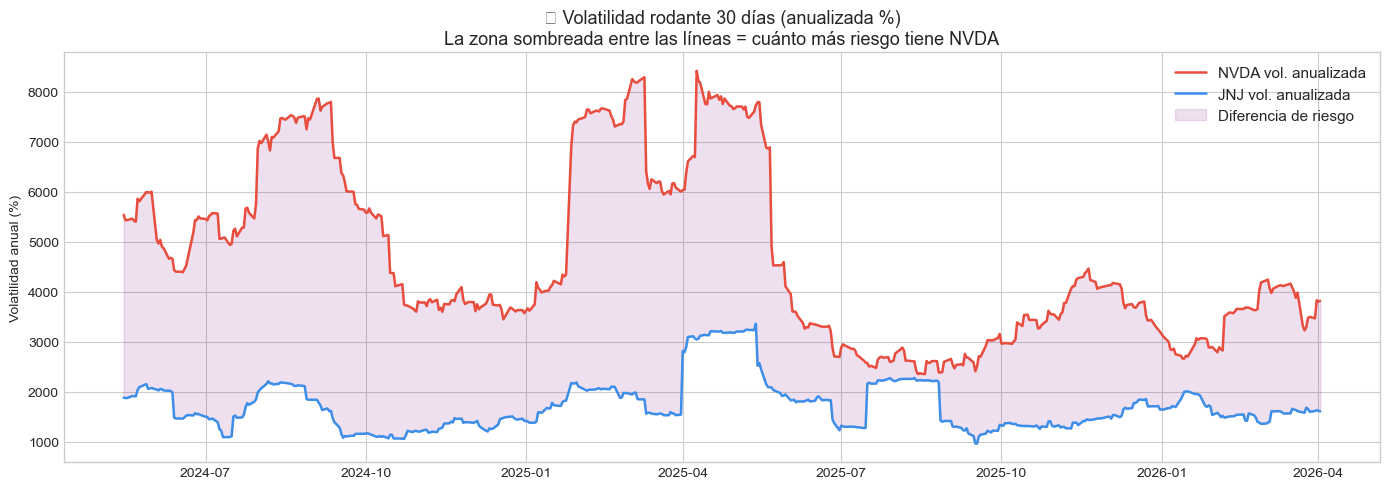

In [10]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 3 — Volatilidad rodante superpuesta
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx_comun, vol_roll_nvda[idx_comun] * 100,
        color=COLOR_V, linewidth=1.8, label=f"{TICKER_VOLATIL} vol. anualizada")
ax.plot(idx_comun, vol_roll_jnj[idx_comun] * 100,
        color=COLOR_E, linewidth=1.8, label=f"{TICKER_ESTABLE} vol. anualizada")
ax.fill_between(idx_comun,
                vol_roll_nvda[idx_comun] * 100,
                vol_roll_jnj[idx_comun]  * 100,
                alpha=0.12, color="purple", label="Diferencia de riesgo")
ax.set_title(f"③ Volatilidad rodante {VENTANA_ROLL} días (anualizada %)\n"
             "La zona sombreada entre las líneas = cuánto más riesgo tiene NVDA", fontsize=13)
ax.set_ylabel("Volatilidad anual (%)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

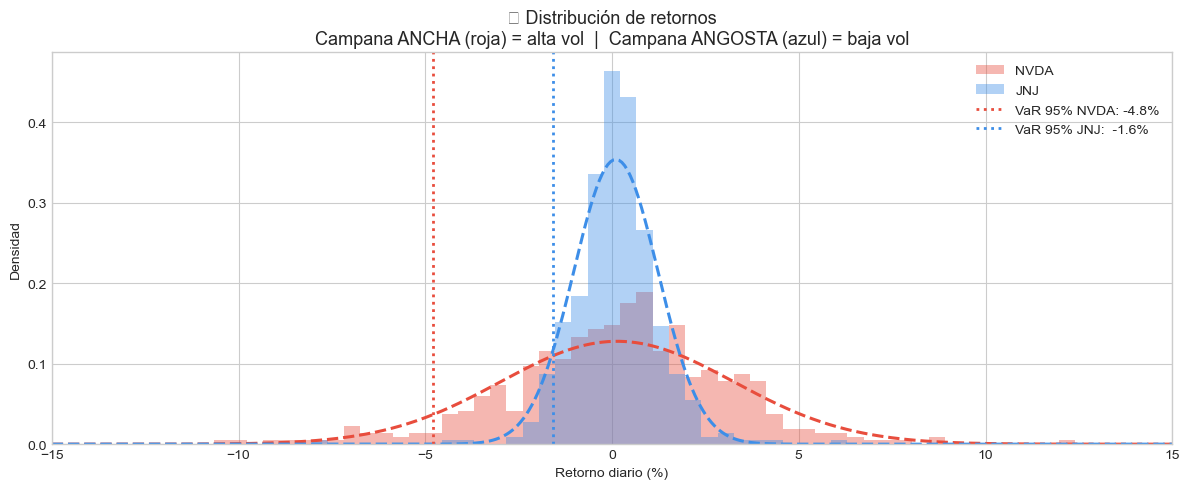

In [11]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 4 — Distribución de retornos (campana ancha vs angosta)
# ══════════════════════════════════════════════════════════════
var_nvda = np.percentile(ret_nvda, 5)
var_jnj  = np.percentile(ret_jnj,  5)

fig, ax = plt.subplots(figsize=(12, 5))
bins = np.linspace(-15, 15, 70)
ax.hist(ret_nvda, bins=bins, density=True, alpha=0.40, color=COLOR_V,
        label=f"{TICKER_VOLATIL}")
ax.hist(ret_jnj,  bins=bins, density=True, alpha=0.40, color=COLOR_E,
        label=f"{TICKER_ESTABLE}")

x_range = np.linspace(-15, 15, 400)
ax.plot(x_range, norm.pdf(x_range, ret_nvda.mean(), ret_nvda.std()),
        color=COLOR_V, linewidth=2.2, linestyle="--")
ax.plot(x_range, norm.pdf(x_range, ret_jnj.mean(),  ret_jnj.std()),
        color=COLOR_E, linewidth=2.2, linestyle="--")

ax.axvline(var_nvda, color=COLOR_V, linestyle=":", linewidth=2,
           label=f"VaR 95% {TICKER_VOLATIL}: {var_nvda:.1f}%")
ax.axvline(var_jnj,  color=COLOR_E, linestyle=":", linewidth=2,
           label=f"VaR 95% {TICKER_ESTABLE}:  {var_jnj:.1f}%")

ax.set_title("④ Distribución de retornos\n"
             "Campana ANCHA (roja) = alta vol  |  Campana ANGOSTA (azul) = baja vol",
             fontsize=13)
ax.set_xlabel("Retorno diario (%)")
ax.set_ylabel("Densidad")
ax.set_xlim(-15, 15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

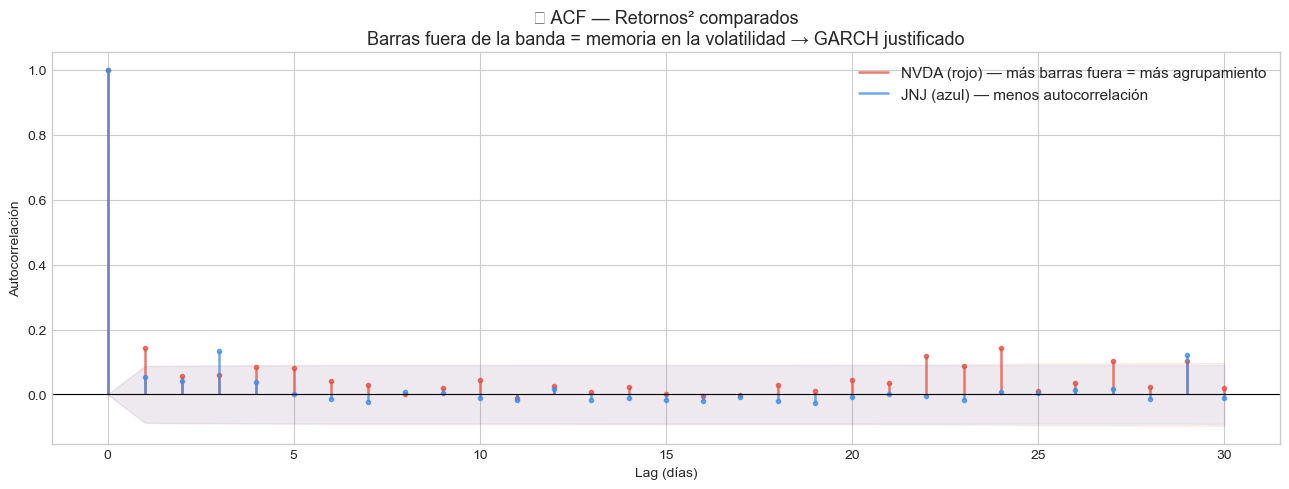

In [12]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 5 — ACF de retornos² (ambas en el mismo panel)
# ══════════════════════════════════════════════════════════════
def dibujar_acf(ax, serie, lags, color, label):
    vals, ci = acf(serie, nlags=lags, alpha=0.05, fft=True)
    x = np.arange(len(vals))
    ax.vlines(x, 0, vals, color=color, linewidth=1.8, alpha=0.75, label=label)
    ax.plot(x, vals, "o", color=color, markersize=3, alpha=0.75)
    banda = ci[:, 1] - vals
    ax.fill_between(x, -banda, banda, alpha=0.08, color=color)

def dibujar_pacf(ax, serie, lags, color, label):
    vals, ci = pacf(serie, nlags=lags, alpha=0.05, method="ywm")
    x = np.arange(len(vals))
    ax.vlines(x, 0, vals, color=color, linewidth=1.8, alpha=0.75, label=label)
    ax.plot(x, vals, "o", color=color, markersize=3, alpha=0.75)
    banda = ci[:, 1] - vals
    ax.fill_between(x, -banda, banda, alpha=0.08, color=color)

fig, ax = plt.subplots(figsize=(13, 5))
dibujar_acf(ax, ret_nvda**2, LAGS, COLOR_V,
            f"{TICKER_VOLATIL} (rojo) — más barras fuera = más agrupamiento")
dibujar_acf(ax, ret_jnj**2,  LAGS, COLOR_E,
            f"{TICKER_ESTABLE} (azul) — menos autocorrelación")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("⑤ ACF — Retornos² comparados\n"
             "Barras fuera de la banda = memoria en la volatilidad → GARCH justificado",
             fontsize=13)
ax.set_xlabel("Lag (días)")
ax.set_ylabel("Autocorrelación")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

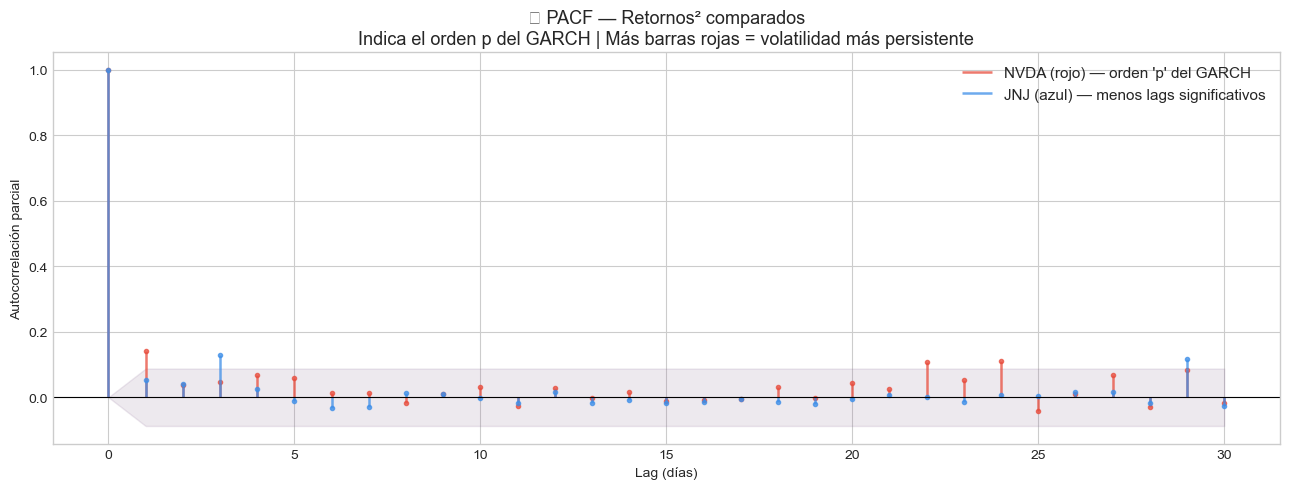

In [13]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 6 — PACF de retornos² (ambas en el mismo panel)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))
dibujar_pacf(ax, ret_nvda**2, LAGS, COLOR_V,
             f"{TICKER_VOLATIL} (rojo) — orden 'p' del GARCH")
dibujar_pacf(ax, ret_jnj**2,  LAGS, COLOR_E,
             f"{TICKER_ESTABLE} (azul) — menos lags significativos")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("⑥ PACF — Retornos² comparados\n"
             "Indica el orden p del GARCH | Más barras rojas = volatilidad más persistente",
             fontsize=13)
ax.set_xlabel("Lag (días)")
ax.set_ylabel("Autocorrelación parcial")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
# ─── TABLA RESUMEN FINAL ──────────────────────────────────────
lb_nvda = acorr_ljungbox(ret_nvda**2, lags=[5, 12], return_df=True)
lb_jnj  = acorr_ljungbox(ret_jnj**2,  lags=[5, 12], return_df=True)

resumen = pd.DataFrame({
    "Métrica"            : ["Vol. diaria (%)", "Vol. anualizada (%)",
                            "Retorno medio diario (%)", "Peor día (%)",
                            "VaR histórico 95% (%)"],
    f"🔴 {TICKER_VOLATIL}": [f"{vol_d_nvda:.2f}", f"{vol_a_nvda:.1f}",
                              f"{ret_nvda.mean():.3f}", f"{ret_nvda.min():.2f}",
                              f"{var_nvda:.2f}"],
    f"🔵 {TICKER_ESTABLE}" : [f"{vol_d_jnj:.2f}",  f"{vol_a_jnj:.1f}",
                              f"{ret_jnj.mean():.3f}",  f"{ret_jnj.min():.2f}",
                              f"{var_jnj:.2f}"],
})

print("\n" + "="*60)
print("  RESUMEN COMPARATIVO DE VOLATILIDAD")
print("="*60)
display(resumen)

print(f"\n🔑 {TICKER_VOLATIL} es {vol_a_nvda/vol_a_jnj:.1f}x más volátil que {TICKER_ESTABLE}")
print(f"\nLjung-Box retornos² — p < 0.05 confirma GARCH válido:")
print(f"\n🔴 {TICKER_VOLATIL}:\n{lb_nvda.round(4).to_string()}")
print(f"\n🔵 {TICKER_ESTABLE}:\n{lb_jnj.round(4).to_string()}")


  RESUMEN COMPARATIVO DE VOLATILIDAD


,Métrica,🔴 NVDA,🔵 JNJ
0,Vol. diaria (%),3.12,1.13
1,Vol. anualizada (%),49.6,17.9
2,Retorno medio diario (%),0.138,0.103
3,Peor día (%),-18.59,-7.90
4,VaR histórico 95% (%),-4.80,-1.59



🔑 NVDA es 2.8x más volátil que JNJ

Ljung-Box retornos² — p < 0.05 confirma GARCH válido:

🔴 NVDA:
    lb_stat  lb_pvalue
5   20.4224     0.0010
12  23.3496     0.0249

🔵 JNJ:
    lb_stat  lb_pvalue
5   11.9863      0.035
12  12.7423      0.388
